In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [27]:
# load dataset 'dataset_1980_2020.csv'
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


## EDA

#### Total number of Crimes vs Year

Total number of crime across all years:  51162


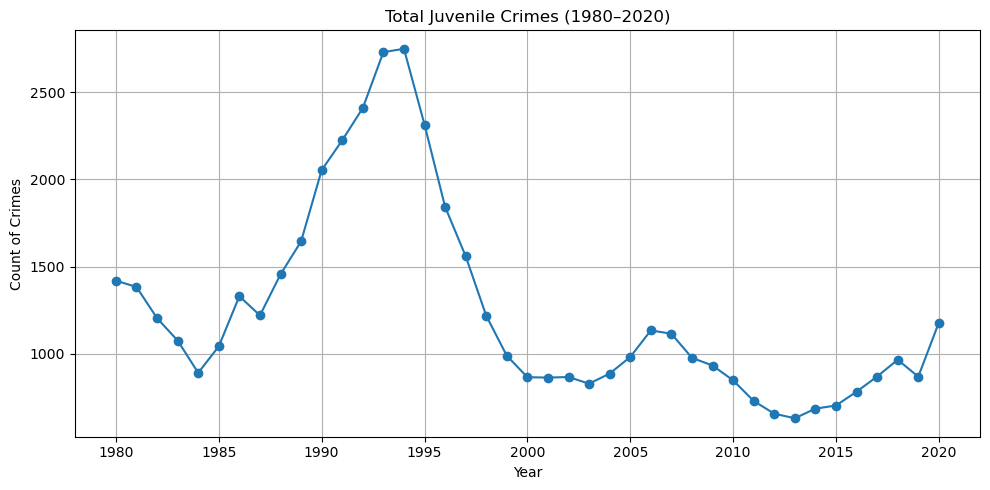

In [35]:
eda_data = raw_data.copy()
eda_data['Total'] = eda_data['0 to 11'] + eda_data['12 to 17']
yearly_totals = eda_data.groupby('Year')['Total'].sum()
print("Total number of crime across all years: ",sum(yearly_totals))

plt.figure(figsize=(10, 5))
plt.plot(yearly_totals.index, yearly_totals.values, marker='o')
plt.title("Total Juvenile Crimes (1980–2020)")
plt.xlabel("Year")
plt.ylabel("Count of Crimes")
plt.grid()
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Total Juvenile Crime by State'}, xlabel='State'>

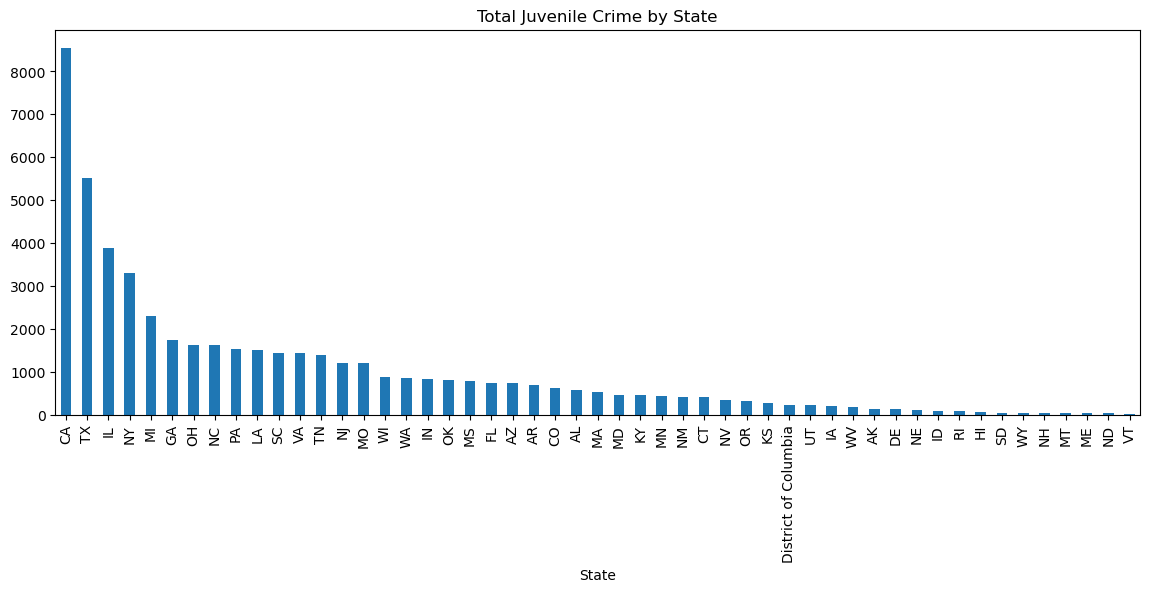

In [ ]:
state_totals = eda_data.groupby('State')['Total'].sum().sort_values(ascending=False)
state_totals.plot(kind='bar', figsize=(14, 5), title="Total Juvenile Crime by State (1980-2020)")

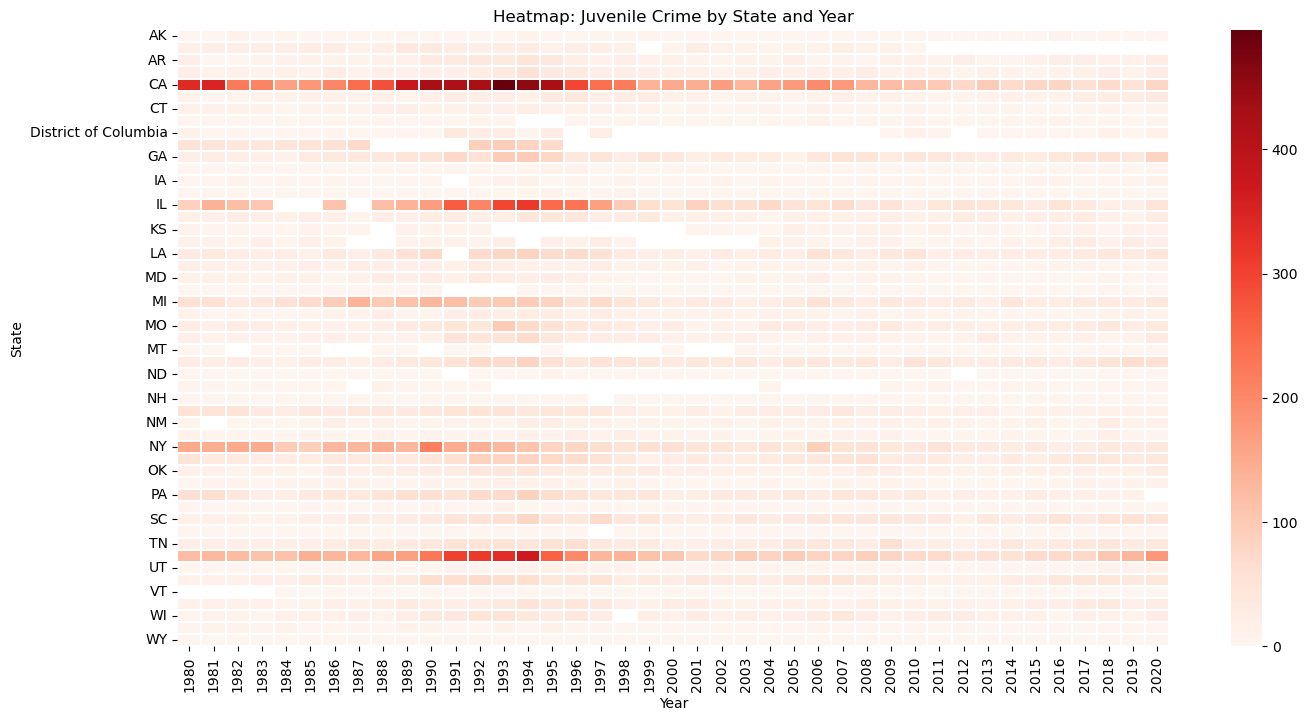

In [ ]:
# Show intensity
pivot = eda_data.pivot_table(index='State', columns='Year', values='Total', aggfunc='sum')
plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap="Reds", linewidths=0.1)
plt.title("Heatmap: Juvenile Crime by State and Year")
plt.show()